In [1]:
import pandas as pd
print("pandas imported ✅")

pandas imported ✅


In [2]:
df = pd.read_csv('/Users/riyarastogi/Desktop/da_portfolio/data/raw/city_day.csv')
print("Shape:", df.shape)
df.head()

Shape: (18265, 16)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

print("All imports successful ✅")

All imports successful ✅


In [4]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNS ===")
print(df.columns.tolist())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== FIRST 5 ROWS ===")
df.head()

=== SHAPE ===
(18265, 16)

=== COLUMNS ===
['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

=== DATA TYPES ===
City              str
Datetime          str
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket        str
dtype: object

=== FIRST 5 ROWS ===


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [5]:
print("=== NULL VALUES PER COLUMN ===")
null_df = pd.DataFrame({
    'Column': df.columns,
    'Null Count': df.isnull().sum().values,
    'Null %': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(null_df.to_string(index=False))

=== NULL VALUES PER COLUMN ===
    Column  Null Count  Null %
      City           0     0.0
  Datetime           0     0.0
     PM2.5           0     0.0
      PM10           0     0.0
        NO           0     0.0
       NO2           0     0.0
       NOx           0     0.0
       NH3           0     0.0
        CO           0     0.0
       SO2           0     0.0
        O3           0     0.0
   Benzene           0     0.0
   Toluene           0     0.0
    Xylene           0     0.0
       AQI           0     0.0
AQI_Bucket           0     0.0


<Figure size 1200x500 with 0 Axes>

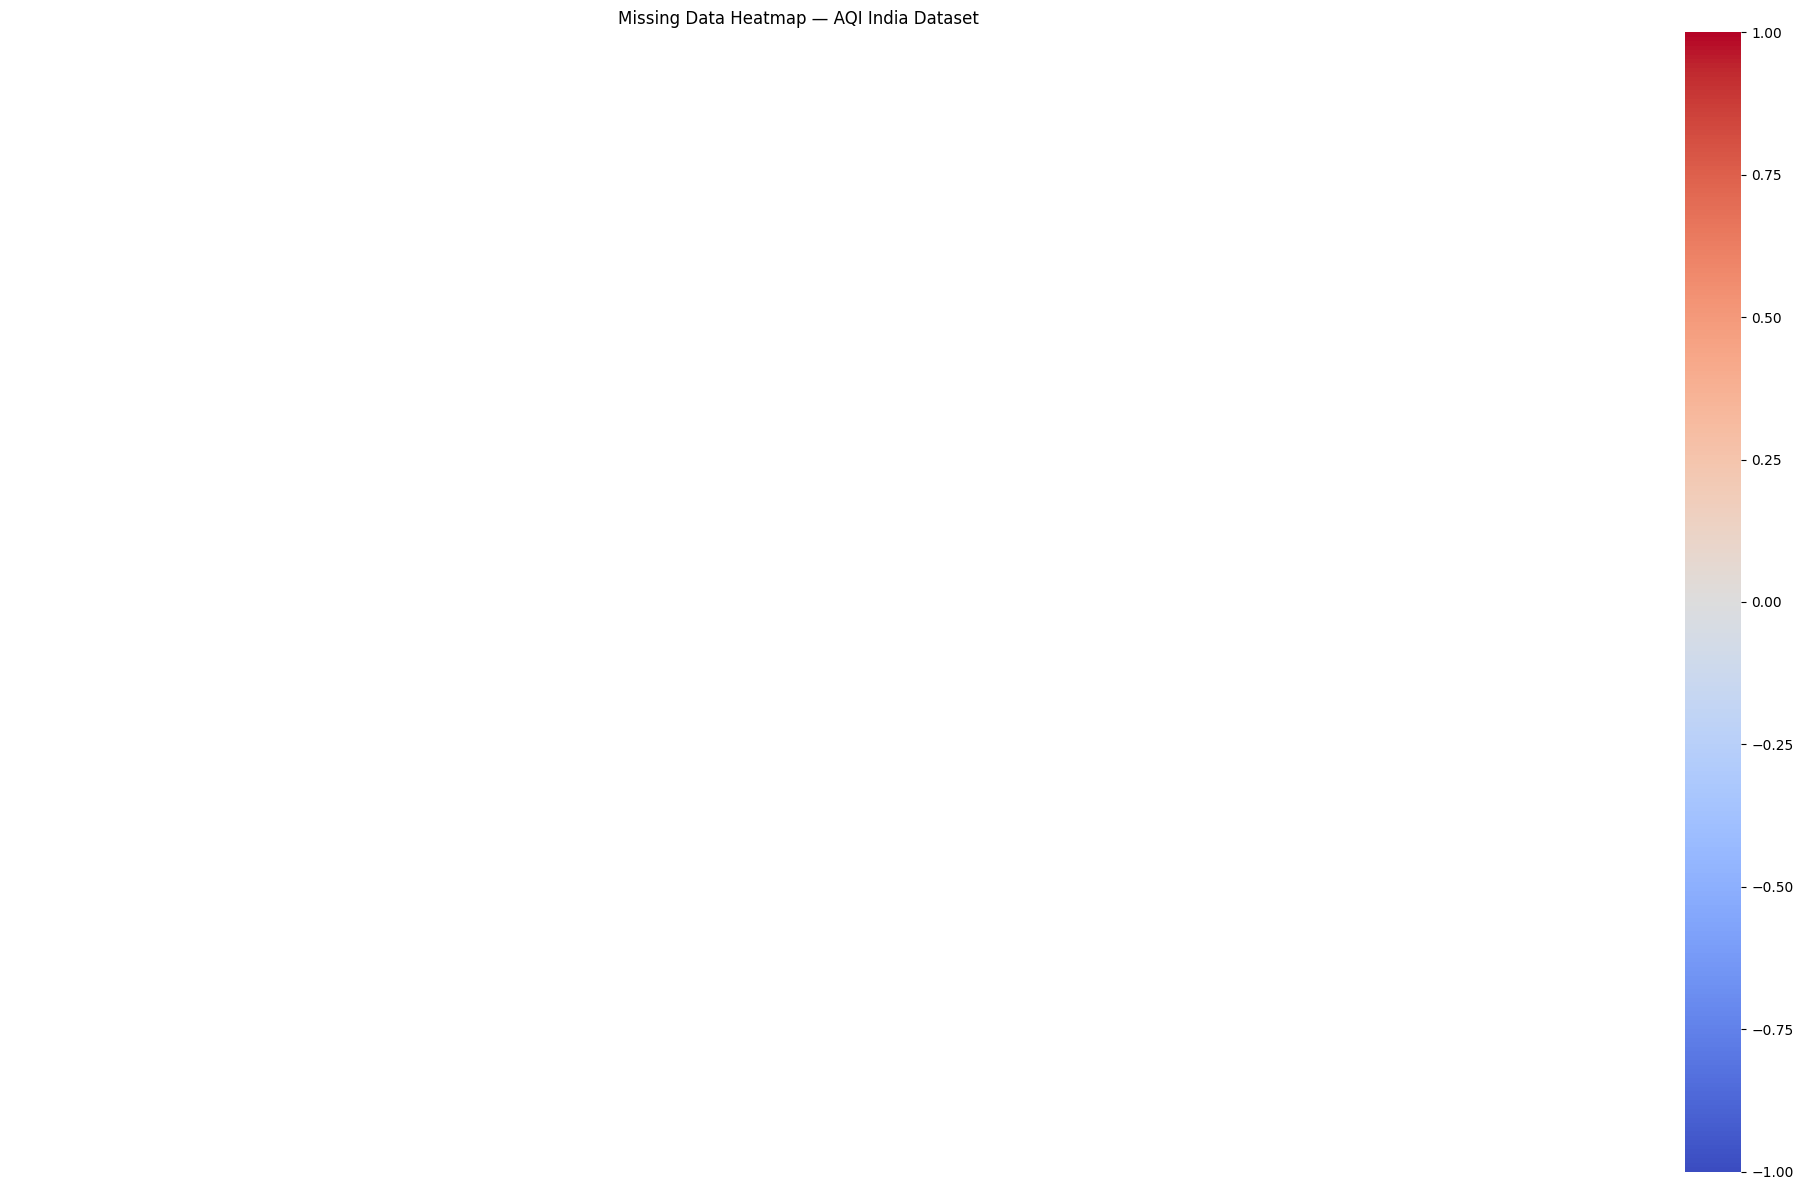

Chart saved ✅


In [6]:
plt.figure(figsize=(12, 5))
msno.heatmap(df, cmap='coolwarm')
plt.title('Missing Data Heatmap — AQI India Dataset')
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/missing_data_heatmap.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [8]:
df['Date'] = pd.to_datetime(df['Datetime'])
print("Date dtype:", df['Datetime'].dtype)
print("Date range:", df['Datetime'].min(), "to", df['Date'].max())

Date dtype: str
Date range: 2015-01-01 to 2024-12-31 00:00:00


In [9]:
before = len(df)
df = df.drop_duplicates(subset=['City', 'Date'])
after = len(df)
print(f"Duplicates removed: {before - after}")
print(f"Rows remaining: {after}")

Duplicates removed: 0
Rows remaining: 18265


In [10]:
# Drop rows where AQI is null — it's our primary metric
before = len(df)
df = df.dropna(subset=['AQI', 'AQI_Bucket'])
print(f"Rows dropped (null AQI): {before - len(df)}")

# Fill pollutant nulls with city median
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']

for col in pollutants:
    if col in df.columns:
        df[col] = df.groupby('City')[col].transform(
            lambda x: x.fillna(x.median())
        )

print("Pollutant nulls filled with city median ✅")
print("\nRemaining nulls:")
print(df.isnull().sum())

Rows dropped (null AQI): 0
Pollutant nulls filled with city median ✅

Remaining nulls:
City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Date          0
dtype: int64


In [11]:
df['City'] = df['City'].str.strip().str.title()
df['AQI_Bucket'] = df['AQI_Bucket'].str.strip().str.title()

print("Cities:", sorted(df['City'].unique()))
print("\nAQI Categories:", sorted(df['AQI_Bucket'].unique()))

Cities: ['Bangalore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai']

AQI Categories: ['Good', 'Moderate', 'Poor', 'Satisfactory', 'Severe', 'Very Poor']


AQI Outliers detected: 0
Normal AQI range: -251.1 to 752.9


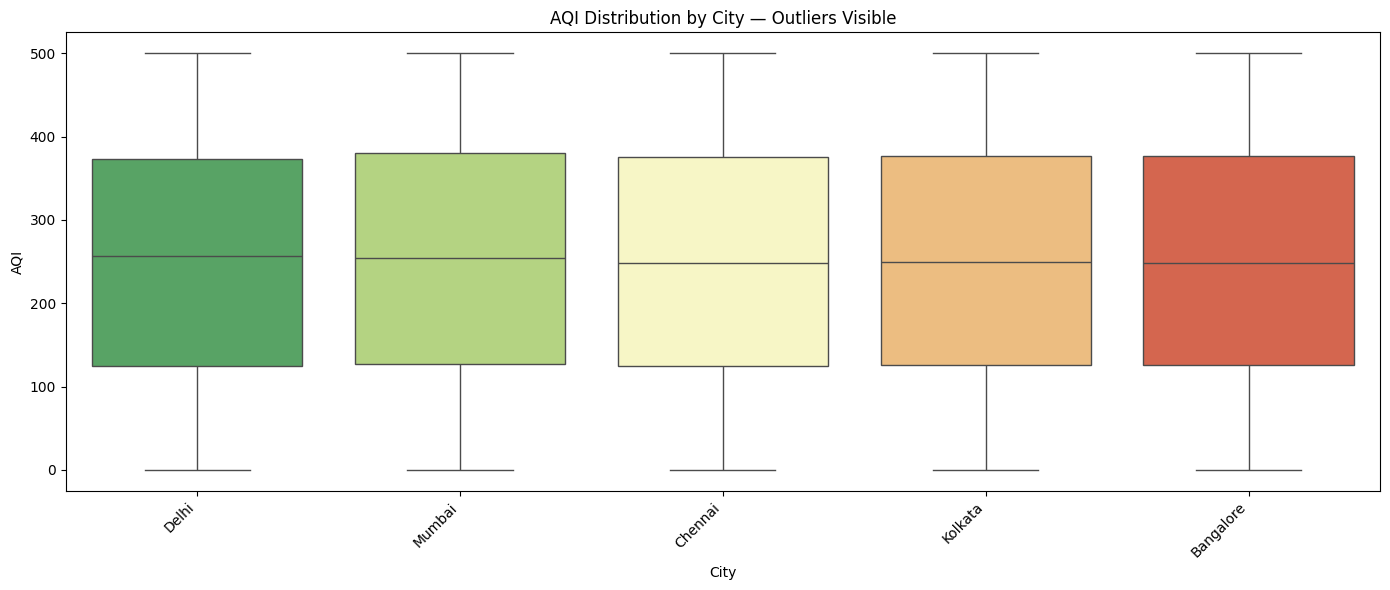

Chart saved ✅


In [12]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['AQI'] < lower) | (df['AQI'] > upper)]
print(f"AQI Outliers detected: {len(outliers)}")
print(f"Normal AQI range: {lower:.1f} to {upper:.1f}")

# Flag but don't remove — real pollution events!
df['AQI_Outlier_Flag'] = ((df['AQI'] < lower) | (df['AQI'] > upper)).astype(int)

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='City', y='AQI', palette='RdYlGn_r')
plt.xticks(rotation=45, ha='right')
plt.title('AQI Distribution by City — Outliers Visible')
plt.tight_layout()
plt.savefig('/Users/riyarastogi/Desktop/da_portfolio/exports/aqi_boxplot.png', dpi=150)
plt.show()
print("Chart saved ✅")

In [13]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

print("New columns added ✅")
df[['City', 'Date', 'Year', 'Month', 'Month_Name', 'AQI']].head()

New columns added ✅


,City,Date,Year,Month,Month_Name,AQI
0,Delhi,2015-01-01,2015,1,January,204.5
1,Mumbai,2015-01-01,2015,1,January,60.9
2,Chennai,2015-01-01,2015,1,January,486.5
3,Kolkata,2015-01-01,2015,1,January,174.4
4,Bangalore,2015-01-01,2015,1,January,489.7


In [14]:
df.to_csv('/Users/riyarastogi/Desktop/da_portfolio/data/cleaned/cleaned_data.csv', index=False)
print("Cleaned data saved ✅")
print(f"Location: data/cleaned/cleaned_data.csv")
print(f"Final shape: {df.shape}")

Cleaned data saved ✅
Location: data/cleaned/cleaned_data.csv
Final shape: (18265, 21)


In [15]:
print("=" * 40)
print("   DATA QUALITY SCORECARD")
print("=" * 40)
print(f"  Total rows (final):     {len(df):,}")
print(f"  Total cities:           {df['City'].nunique()}")
print(f"  Date range:             {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"  Null values remaining:  {df.isnull().sum().sum()}")
print(f"  Outliers flagged:       {df['AQI_Outlier_Flag'].sum()}")
print(f"  AQI categories:         {df['AQI_Bucket'].nunique()}")
print("=" * 40)
print("  Status: CLEAN ✅")
print("=" * 40)

   DATA QUALITY SCORECARD
  Total rows (final):     18,265
  Total cities:           5
  Date range:             2015-01-01 → 2024-12-31
  Null values remaining:  0
  Outliers flagged:       0
  AQI categories:         6
  Status: CLEAN ✅
